In [49]:
import h5py, glob
import matplotlib.pyplot as plt
files = glob.glob('/suphys/aani0116/Work/minicluster_tidal/hpc/*.h5')
for i,j in enumerate(files):
    print(i, files[i])

0 /suphys/aani0116/Work/minicluster_tidal/hpc/mc6_m1.0e-06_c10_d10.h5
1 /suphys/aani0116/Work/minicluster_tidal/hpc/mc4_m1.0e-06_c10_d10.h5
2 /suphys/aani0116/Work/minicluster_tidal/hpc/mc10C_small_m1.0e-06_c10_d10.h5
3 /suphys/aani0116/Work/minicluster_tidal/hpc/mc10C_small2_meitner_m1.0e-06_c10_d10.h5


In [50]:
with h5py.File(files[3], 'r') as f:
    mcp_xv     = f['mcp_xv'][:]
    bound      = f['bound'][:]
    E_p        = f['E_p'][:]
    mc_xv      = f['mc_xv'][:]
    snap_times = f['snap_times'][:]
    
    mcp_mass        = f.attrs['mcp_mass']
    Nbody           = f.attrs['Nbody']
    simulation_time = f.attrs['simulation_time']
    tupd            = f.attrs['tupd']
    N_orbits        = f.attrs['N_orbits']
    mc_mass         = f.attrs['mc_mass']
    mc_delta        = f.attrs['mc_delta']
    mc_radius       = f.attrs['mc_radius']
    mc_radius_char  = f.attrs['mc_radius_char']
    mc_density_char = f.attrs['mc_density_char']
    mc_concentration= f.attrs['mc_concentration']


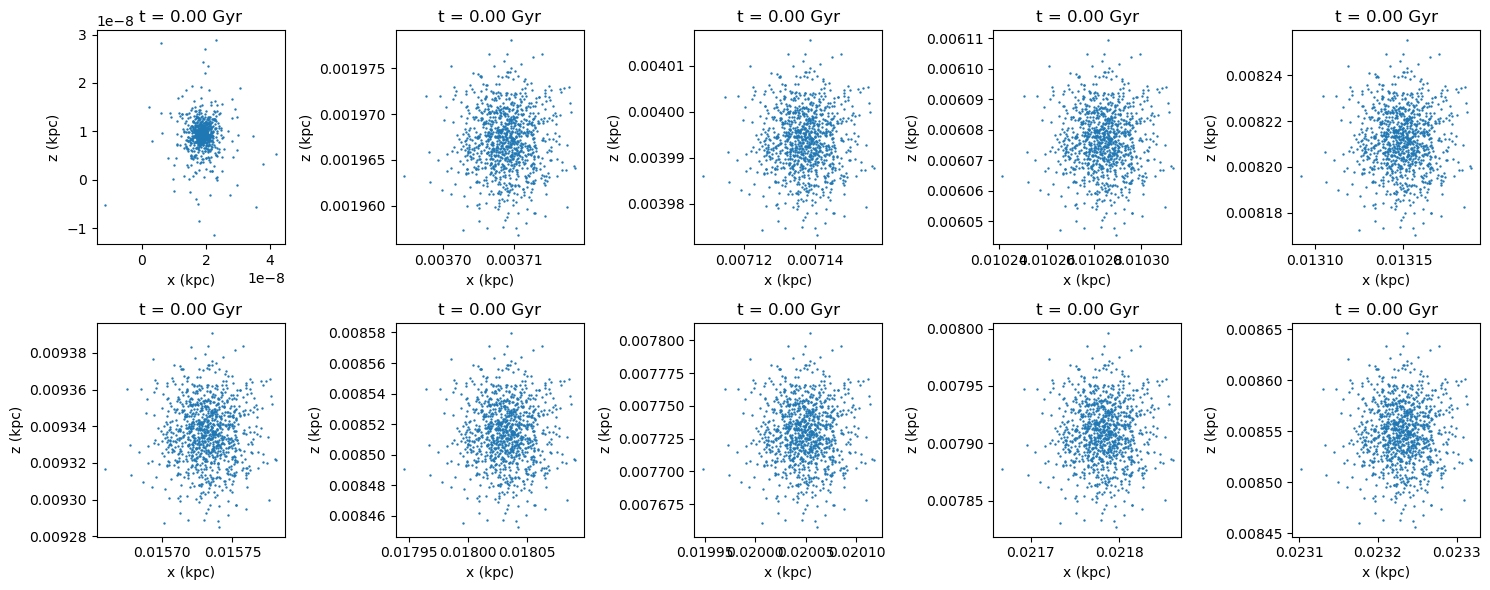

1e-09


In [51]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    ax.scatter(mcp_xv[i, :, 0], mcp_xv[i, :, 2], s=0.5)
    ax.set_title(f't = {snap_times[i]:.2f} Gyr')
    ax.set_xlabel('x (kpc)')
    ax.set_ylabel('z (kpc)')

plt.tight_layout()
plt.show()
print(tupd)

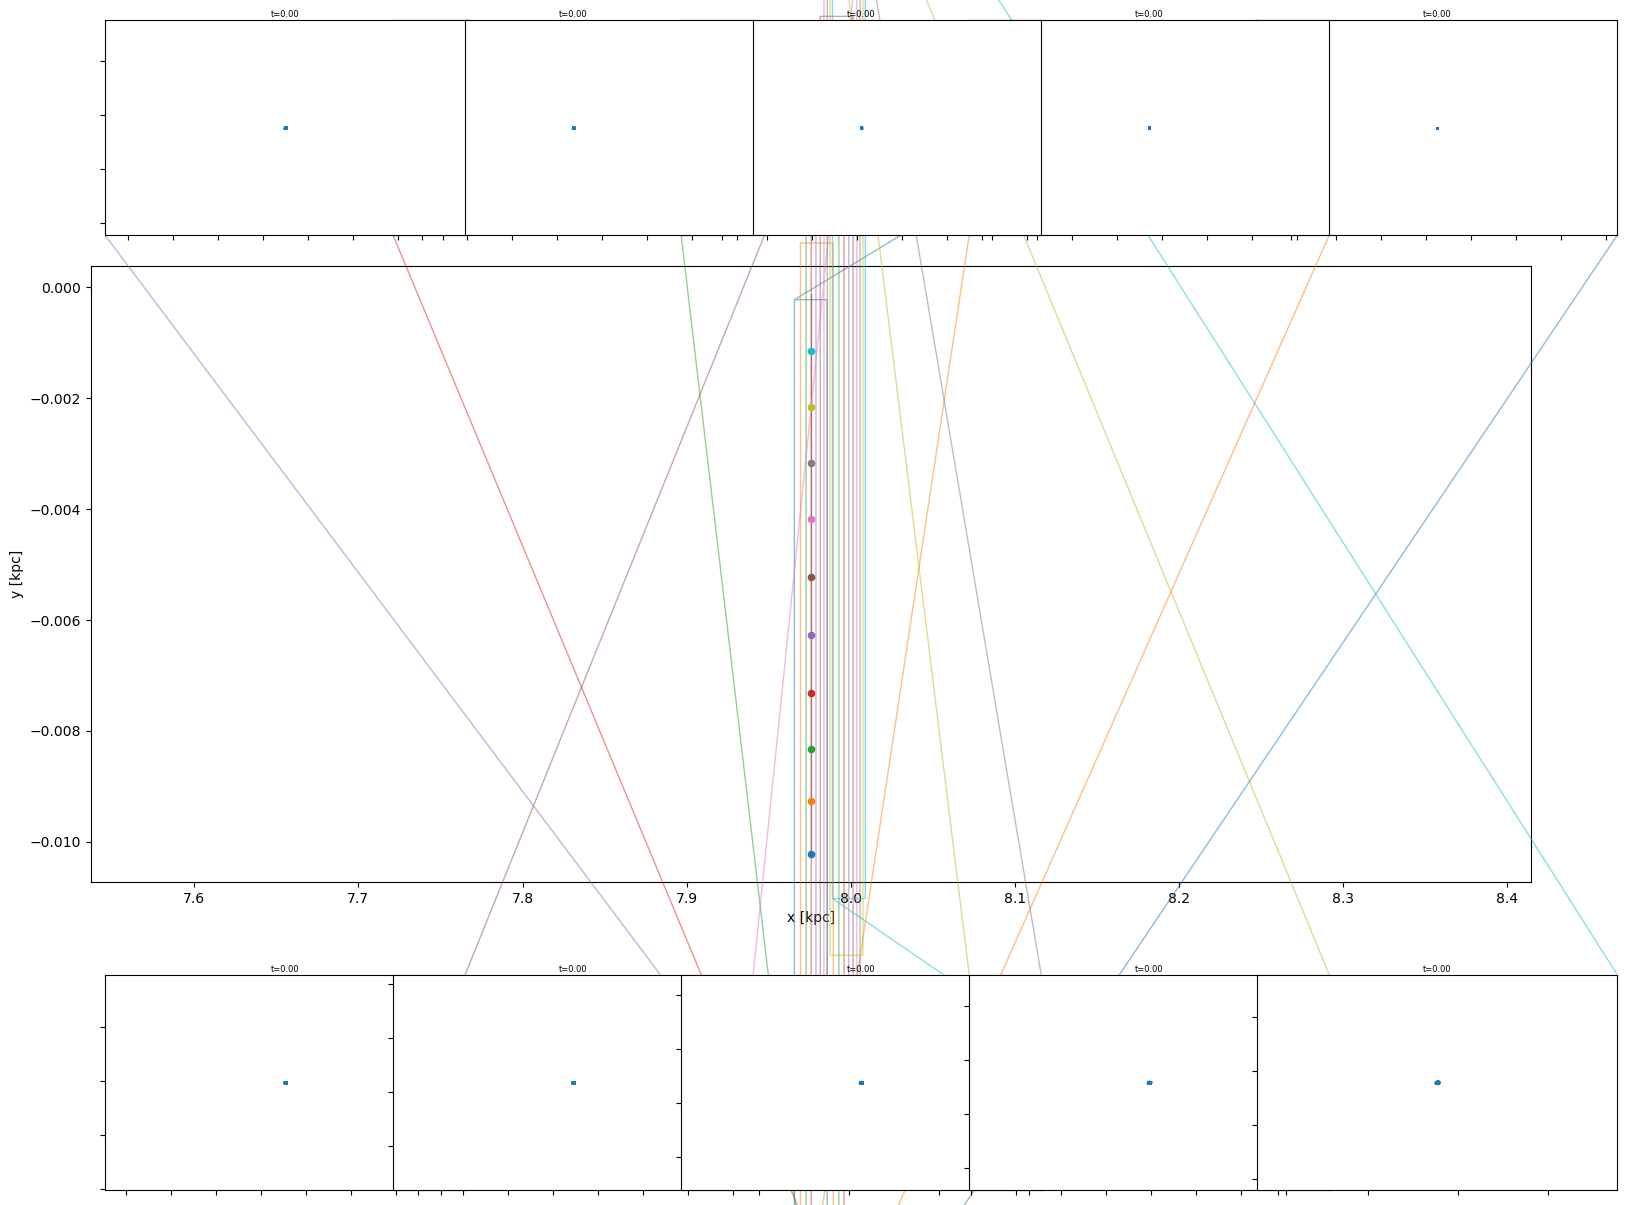

In [52]:
fig, ax = plt.subplots(figsize=(18, 14))
fig.subplots_adjust(left=0.1, right=0.9, top=0.72, bottom=0.28)

ax.plot(mc_xv[:, 0], mc_xv[:, 1], lw=1, color='gray', alpha=0.7)
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')

# 5 above, 5 below
inset_positions = (
    [[0.01 + 0.2*i, 1.05, 0.25, 0.35] for i in range(4, -1, -1)] +
    [[0.01 + 0.2*i, -0.50, 0.25, 0.35] for i in range(5)]
)




for i, pos in enumerate(inset_positions):
    axz = ax.inset_axes(pos)
    axz.scatter(mcp_xv[i, :, 0] + mc_xv[i, 0], mcp_xv[i, :, 1] + mc_xv[i, 1], s=0.5, alpha=0.5)
    axz.set_title(f't={snap_times[i]:.2f}', fontsize=6, pad=2)

    x_c = mcp_xv[i, :, 0].mean() + mc_xv[i, 0]
    y_c = mcp_xv[i, :, 1].mean() + mc_xv[i, 1]
    dx = max(mcp_xv[i, :, 0].std() * 4, 0.01)
    dy = max(mcp_xv[i, :, 1].std() * 4, 0.01)
    axz.set_xlim(x_c - dx, x_c + dx)
    axz.set_ylim(y_c - dy, y_c + dy)
    axz.set_xticklabels([])
    axz.set_yticklabels([])

    ax.scatter(mc_xv[i, 0], mc_xv[i, 1], s=20, zorder=5, color=f'C{i}')
    ax.indicate_inset_zoom(axz, edgecolor=f'C{i}')

plt.show()


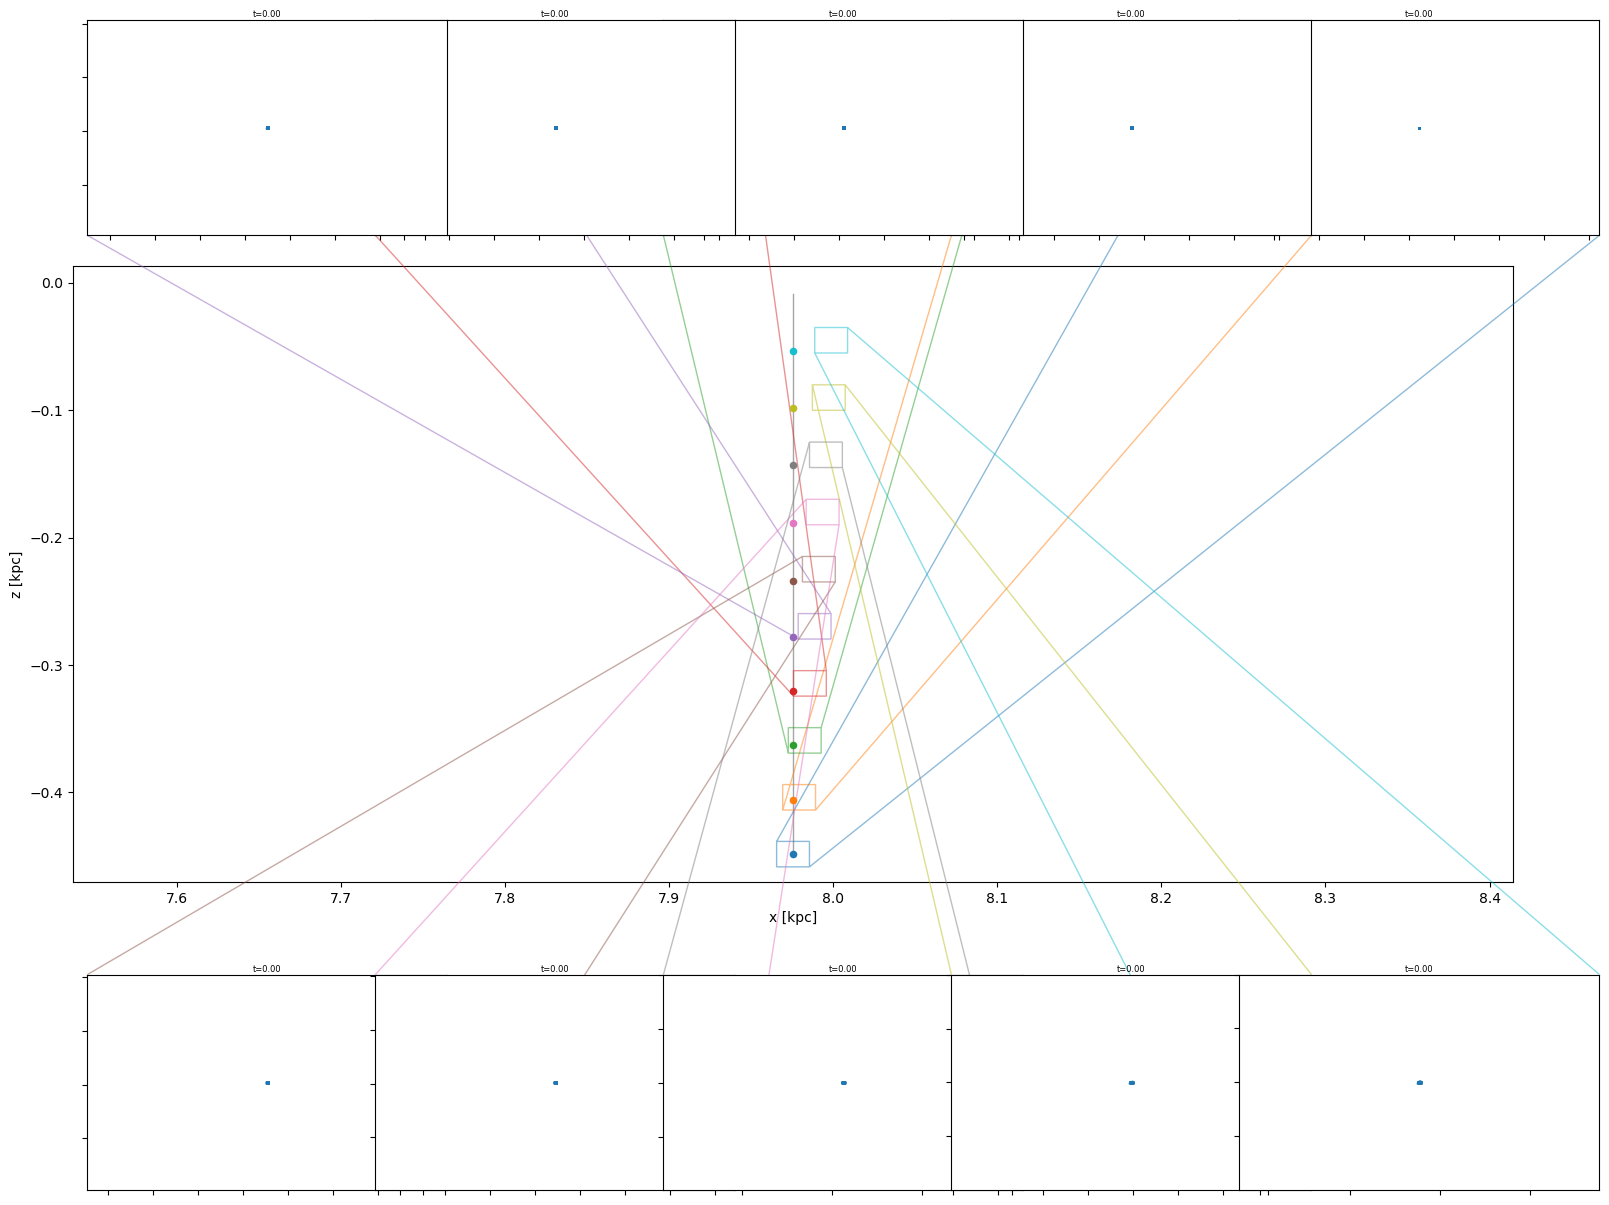

In [53]:
x, y = 0, 2

fig, ax = plt.subplots(figsize=(18, 14))
fig.subplots_adjust(left=0.1, right=0.9, top=0.72, bottom=0.28)

ax.plot(mc_xv[:, x], mc_xv[:, y], lw=1, color='gray', alpha=0.7)
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')

inset_positions = (
    [[0.01 + 0.2*i, 1.05, 0.25, 0.35] for i in range(4, -1, -1)] +
    [[0.01 + 0.2*i, -0.50, 0.25, 0.35] for i in range(5)]
)

for i, pos in enumerate(inset_positions):
    axz = ax.inset_axes(pos)
    axz.scatter(mcp_xv[i, :, x] + mc_xv[i, x], mcp_xv[i, :, y] + mc_xv[i, y], s=0.5, alpha=0.5)
    axz.set_title(f't={snap_times[i]:.2f}', fontsize=6, pad=2)

    x_c = mcp_xv[i, :, x].mean() + mc_xv[i, x]
    y_c = mcp_xv[i, :, y].mean() + mc_xv[i, y]
    dx = max(mcp_xv[i, :, x].std() * 4, 0.01)
    dy = max(mcp_xv[i, :, y].std() * 4, 0.01)
    axz.set_xlim(x_c - dx, x_c + dx)
    axz.set_ylim(y_c - dy, y_c + dy)
    axz.set_xticklabels([])
    axz.set_yticklabels([])

    ax.scatter(mc_xv[i, x], mc_xv[i, y], s=20, zorder=5, color=f'C{i}')
    ax.indicate_inset_zoom(axz, edgecolor=f'C{i}')

plt.show()


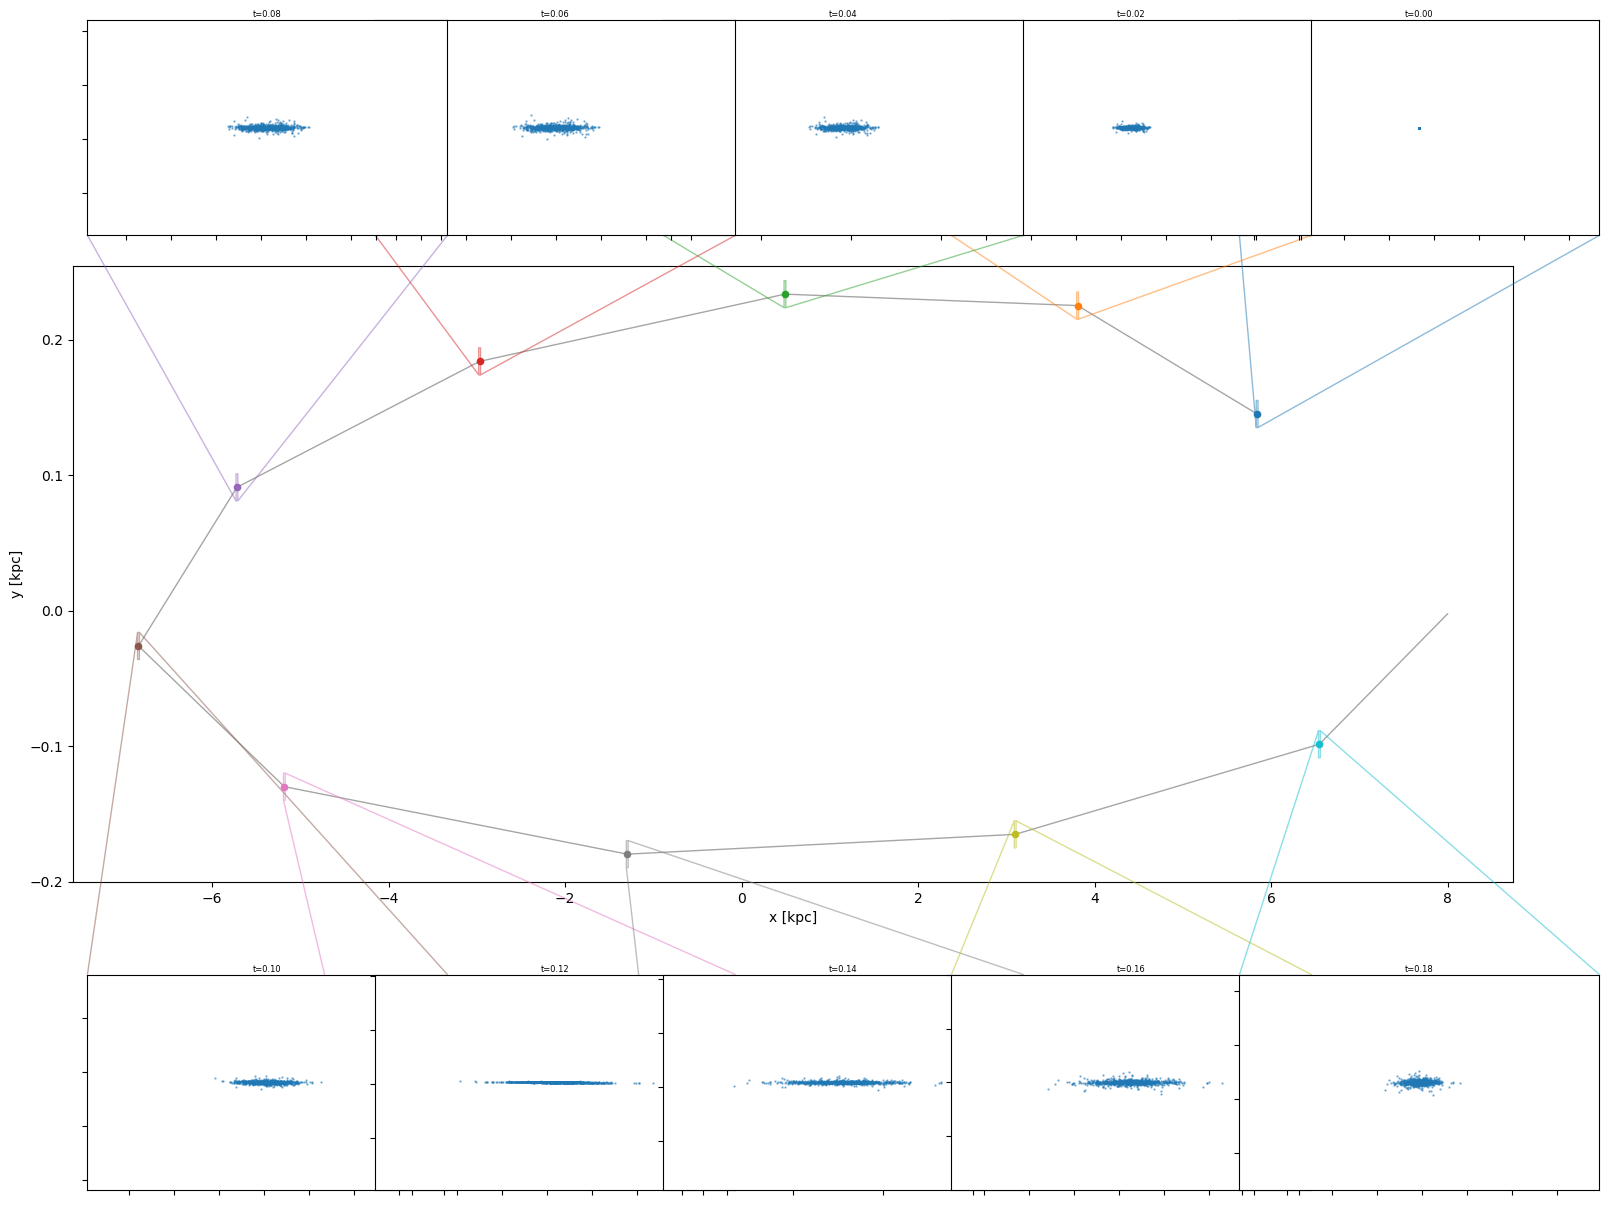

In [35]:
x, y = 0,1 

fig, ax = plt.subplots(figsize=(18, 14))
fig.subplots_adjust(left=0.1, right=0.9, top=0.72, bottom=0.28)

ax.plot(mc_xv[:, x], mc_xv[:, y], lw=1, color='gray', alpha=0.7)
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')

inset_positions = (
    [[0.01 + 0.2*i, 1.05, 0.25, 0.35] for i in range(4, -1, -1)] +
    [[0.01 + 0.2*i, -0.50, 0.25, 0.35] for i in range(5)]
)

for i, pos in enumerate(inset_positions):
    axz = ax.inset_axes(pos)
    axz.scatter(mcp_xv[i, :, x] + mc_xv[i, x], mcp_xv[i, :, y] + mc_xv[i, y], s=0.5, alpha=0.5)
    axz.set_title(f't={snap_times[i]:.2f}', fontsize=6, pad=2)

    x_c = mcp_xv[i, :, x].mean() + mc_xv[i, x]
    y_c = mcp_xv[i, :, y].mean() + mc_xv[i, y]
    dx = max(mcp_xv[i, :, x].std() * 4, 0.01)
    dy = max(mcp_xv[i, :, y].std() * 4, 0.01)
    axz.set_xlim(x_c - dx, x_c + dx)
    axz.set_ylim(y_c - dy, y_c + dy)
    axz.set_xticklabels([])
    axz.set_yticklabels([])

    ax.scatter(mc_xv[i, x], mc_xv[i, y], s=20, zorder=5, color=f'C{i}')
    ax.indicate_inset_zoom(axz, edgecolor=f'C{i}')

plt.show()
